<a href="https://colab.research.google.com/github/logansivam/Testing/blob/main/AIMiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection System
**Course:** IAS2313 Artificial Intelligence — Mini Project

| Role | Member | Responsibility |
|------|--------|---------------|
| Data Engineer | Logan | Data cleaning & preprocessing |
| ML Engineer | Tengku | Model training & tuning |
| System Developer | Syed | Streamlit interface |
| Evaluation & Docs | Thaya | Metrics & report |

# 0. Setup

Upload `AI_dataset.zip` to Colab and run the cell below to extract the dataset files. If running locally, skip this cell.

In [ ]:
import os

# --- Detect environment ---
try:
    from google.colab import files
    IN_COLAB = True
    print('Running on Google Colab')
except ImportError:
    IN_COLAB = False
    print('Running locally')

# --- Upload & extract on Colab ---
if IN_COLAB:
    import zipfile
    print('Please upload AI_dataset.zip...')
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    with zipfile.ZipFile(zip_name, 'r') as z:
        for member in z.namelist():
            if member.endswith('.csv'):
                filename = os.path.basename(member)
                with z.open(member) as src, open(filename, 'wb') as dst:
                    dst.write(src.read())
                print(f'  Extracted: {filename}')
    DATA_PATH = 'WELFake_Dataset.csv'
else:
    DATA_PATH = os.path.join('AI_dataset', 'AI_dataset', 'WELFake_Dataset.csv')

print(f'\nDataset path: {DATA_PATH}')

Running on Google Colab
Please upload AI_dataset.zip...


KeyboardInterrupt: 

# 1. Data Loading

We use the **WELFake Dataset** (72k+ records) which aggregates news articles from multiple sources with binary labels for fake news classification.

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Fake News Detection/WELFake_Dataset.csv'
df = pd.read_csv(file_path)
print(f'Loaded {len(df):,} records')
print(f'Columns: {list(df.columns)}')
print(f'\nLabel distribution (before fix):')
print(df['label'].value_counts())

Loaded 72,134 records
Columns: ['Unnamed: 0', 'title', 'text', 'label']

Label distribution (before fix):
label
1    37106
0    35028
Name: count, dtype: int64


# 2. Data Preprocessing

The preprocessing pipeline addresses the critical requirements:

* **Label Correction**: The WELFake dataset uses 0=Real, 1=Fake (inverted). We flip to standard convention: **0=Fake, 1=Real**.
* **Handling Missing Values**: Remove rows with empty text, fill missing titles.
* **Deduplication**: Remove 9k+ duplicate texts to prevent data leakage.
* **Text Cleaning**: Lowercase, remove URLs, HTML tags, special characters.
* **Encoding**: TF-IDF vectorization (10,000 features) converts text to numerical data. Feature scaling is not needed since TF-IDF scores are naturally bounded between 0 and 1.

In [ ]:
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Handle Missing Values ---
print('Missing values before cleaning:')
print(df.isnull().sum())

df['title'] = df['title'].fillna('No Title')
df.dropna(subset=['text'], inplace=True)

# --- Fix Labels ---
# WELFake convention: 0=Real, 1=Fake. Flip to standard: 0=Fake, 1=Real
df['label'] = 1 - df['label']
print(f'\nLabels flipped to standard convention (0=Fake, 1=Real)')

# --- Remove Duplicates ---
before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first')
print(f'Removed {before - len(df):,} duplicate texts')
print(f'Records after cleaning: {len(df):,}')
print(f'Labels: Real={sum(df["label"]==1):,}, Fake={sum(df["label"]==0):,}')

# --- Text Cleaning ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    return text

print('\nCleaning text...')
df['text'] = df['text'].apply(clean_text)
df['content'] = df['title'] + ' ' + df['text']

# --- TF-IDF Vectorization ---
print('Vectorizing with TF-IDF (max_features=10000)...')
tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
X = tfidf.fit_transform(df['content'])
y = df['label'].values

print(f'\nPreprocessing Complete.')
print(f'Feature Matrix Shape: {X.shape}')

Missing values before cleaning:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

Labels flipped to standard convention (0=Fake, 1=Real)
Removed 9,377 duplicate texts
Records after cleaning: 62,718
Labels: Real=34,620, Fake=28,098

Cleaning text...
Vectorizing with TF-IDF (max_features=10000)...

Preprocessing Complete.
Feature Matrix Shape: (62718, 10000)


# 3. Data Distribution Visualization

We visualize the distribution of Fake vs Real news to confirm our dataset is reasonably balanced for training.

/tmp/ipython-input-901/2623356830.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


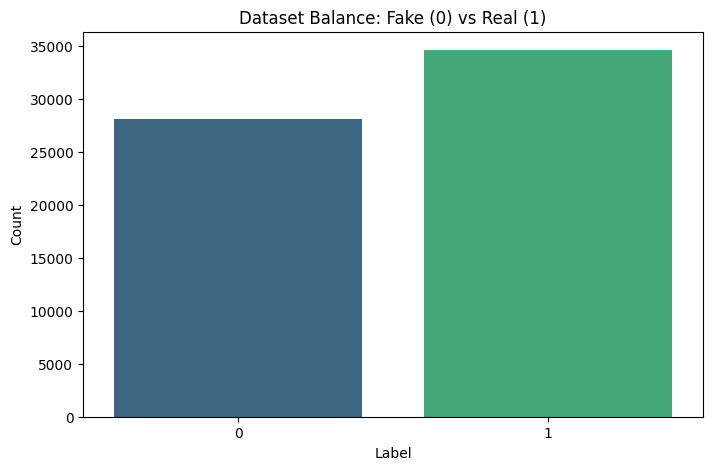

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Dataset Balance: Fake (0) vs Real (1)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# 4. Train-Test Split

We split the data into 80% training and 20% testing sets. The `stratify` parameter ensures both sets maintain the same ratio of Fake to Real news. A fixed `random_state` guarantees reproducible results.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Testing set:  {X_test.shape[0]:,} samples')
print(f'Train labels: Real={sum(y_train==1):,}, Fake={sum(y_train==0):,}')
print(f'Test labels:  Real={sum(y_test==1):,}, Fake={sum(y_test==0):,}')

Training set: 50,174 samples
Testing set:  12,544 samples
Train labels: Real=27,696, Fake=22,478
Test labels:  Real=6,924, Fake=5,620


# 5. Model Training

We train two different classification algorithms to compare their performance:

1. **Logistic Regression** — A fast, interpretable linear model well-suited for high-dimensional text data (TF-IDF features).
2. **Random Forest** — An ensemble method that builds multiple decision trees and aggregates their predictions, capturing non-linear patterns in the data.

## 5.1 Model 1: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import time

print('Training Logistic Regression...')
start = time.time()

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print(f'Training completed in {time.time() - start:.2f}s')

lr_pred = lr_model.predict(X_test)
print(f'\nLogistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Fake', 'Real']))

Training Logistic Regression...
Training completed in 0.80s

Logistic Regression Accuracy: 0.9444

Classification Report:
              precision    recall  f1-score   support

        Fake       0.94      0.94      0.94      5620
        Real       0.95      0.95      0.95      6924

    accuracy                           0.94     12544
   macro avg       0.94      0.94      0.94     12544
weighted avg       0.94      0.94      0.94     12544



## 5.2 Model 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print('Training Random Forest...')
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=50, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

print(f'Training completed in {time.time() - start:.2f}s')

rf_pred = rf_model.predict(X_test)
print(f'\nRandom Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Fake', 'Real']))

Training Random Forest...
Training completed in 238.68s

Random Forest Accuracy: 0.9341

Classification Report:
              precision    recall  f1-score   support

        Fake       0.94      0.92      0.93      5620
        Real       0.93      0.95      0.94      6924

    accuracy                           0.93     12544
   macro avg       0.93      0.93      0.93     12544
weighted avg       0.93      0.93      0.93     12544



# 6. Model Evaluation & Comparison

We evaluate both models using four key metrics: **Accuracy**, **Precision**, **Recall**, and **F1-Score**. The confusion matrices reveal the specific types of errors each model makes, while the bar chart provides a direct visual comparison.

## 6.1 Confusion Matrices

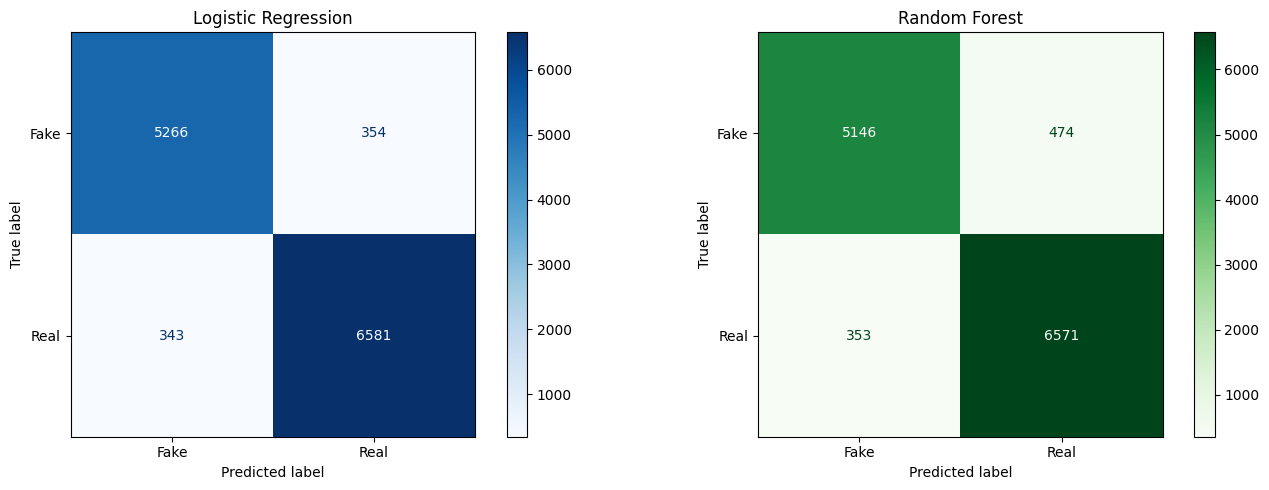

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, display_labels=['Fake', 'Real'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=['Fake', 'Real'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

## 6.2 Performance Comparison

=== Model Performance Comparison ===

                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9444     0.9490  0.9505    0.9497
Random Forest          0.9341     0.9327  0.9490    0.9408


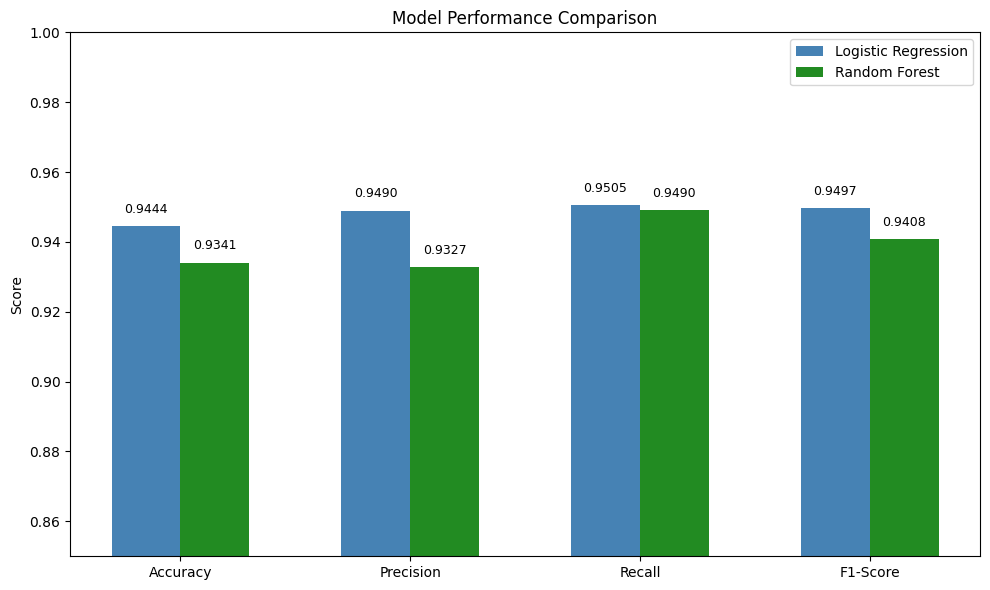


Best Model (by F1-Score): Logistic Regression (0.9497)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

metrics = {
    'Accuracy':  [accuracy_score(y_test, lr_pred),  accuracy_score(y_test, rf_pred)],
    'Precision': [precision_score(y_test, lr_pred),  precision_score(y_test, rf_pred)],
    'Recall':    [recall_score(y_test, lr_pred),     recall_score(y_test, rf_pred)],
    'F1-Score':  [f1_score(y_test, lr_pred),         f1_score(y_test, rf_pred)],
}

metrics_df = pd.DataFrame(metrics, index=['Logistic Regression', 'Random Forest'])
print('=== Model Performance Comparison ===\n')
print(metrics_df.to_string(float_format='{:.4f}'.format))

# --- Bar Chart ---
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, metrics_df.iloc[0], width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, metrics_df.iloc[1], width, label='Random Forest', color='forestgreen')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0.85, 1.0)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best_model_name = metrics_df['F1-Score'].idxmax()
print(f'\nBest Model (by F1-Score): {best_model_name} ({metrics_df.loc[best_model_name, "F1-Score"]:.4f})')

# 7. Hyperparameter Tuning

We use **GridSearchCV** with 3-fold cross-validation to find the best hyperparameters:

* **Logistic Regression**: Regularization strength (`C`)
* **Random Forest**: Number of trees (`n_estimators`) and tree depth (`max_depth`)

In [ ]:
from sklearn.model_selection import GridSearchCV

# --- Tune Logistic Regression ---
print('Tuning Logistic Regression...')
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.1, 1, 10]}, cv=3, scoring='f1', n_jobs=-1
)
lr_grid.fit(X_train, y_train)
print(f'Best params: {lr_grid.best_params_}, CV F1: {lr_grid.best_score_:.4f}')

# --- Tune Random Forest ---
print('\nTuning Random Forest...')
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200, 300], 'max_depth': [30, 50]},
    cv=3, scoring='f1', n_jobs=1, verbose=1
)
rf_grid.fit(X_train, y_train)
print(f'Best params: {rf_grid.best_params_}, CV F1: {rf_grid.best_score_:.4f}')

Tuning Logistic Regression...
Best params: {'C': 10}, CV F1: 0.9518

Tuning Random Forest...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'max_depth': 50, 'n_estimators': 300}, CV F1: 0.9405


## 7.1 Evaluate Tuned Models

In [ ]:
best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_
best_lr_pred = best_lr.predict(X_test)
best_rf_pred = best_rf.predict(X_test)

print('=== Before vs After Tuning ===\n')
print(f'Logistic Regression:')
print(f'  Before: F1={f1_score(y_test, lr_pred):.4f}  Accuracy={accuracy_score(y_test, lr_pred):.4f}')
print(f'  After:  F1={f1_score(y_test, best_lr_pred):.4f}  Accuracy={accuracy_score(y_test, best_lr_pred):.4f}')
print(f'\nRandom Forest:')
print(f'  Before: F1={f1_score(y_test, rf_pred):.4f}  Accuracy={accuracy_score(y_test, rf_pred):.4f}')
print(f'  After:  F1={f1_score(y_test, best_rf_pred):.4f}  Accuracy={accuracy_score(y_test, best_rf_pred):.4f}')

final_models = {
    'Logistic Regression (Tuned)': (best_lr, best_lr_pred),
    'Random Forest (Tuned)': (best_rf, best_rf_pred),
}
best_name = max(final_models, key=lambda k: f1_score(y_test, final_models[k][1]))
best_model, best_pred = final_models[best_name]
print(f'\n>>> Best Overall Model: {best_name}')
print(f'    F1-Score: {f1_score(y_test, best_pred):.4f}')
print(f'    Accuracy: {accuracy_score(y_test, best_pred):.4f}')

=== Before vs After Tuning ===

Logistic Regression:
  Before: F1=0.9497  Accuracy=0.9444
  After:  F1=0.9560  Accuracy=0.9515

Random Forest:
  Before: F1=0.9408  Accuracy=0.9341
  After:  F1=0.9411  Accuracy=0.9344

>>> Best Overall Model: Logistic Regression (Tuned)
    F1-Score: 0.9560
    Accuracy: 0.9515


# 8. Model Export

We save the tuned models and TF-IDF vectorizer using `joblib` so the System Developer can load them into the Streamlit interface for real-time predictions.

In [ ]:
import joblib
from google.colab import files

# 1. Save the newly trained models to the Colab folder
joblib.dump(best_lr, 'logistic_regression_model.joblib')
joblib.dump(best_rf, 'random_forest_model.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')

print('✅ Exported files successfully!')

# 2. Automatically download them to your physical computer
for f in ['logistic_regression_model.joblib', 'random_forest_model.joblib', 'tfidf_vectorizer.joblib']:
    files.download(f)

✅ Exported files successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.0 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import joblib

# 1. Load the models and vectorizer safely
@st.cache_resource
def load_system():
    try:
        lr_model = joblib.load('/content/logistic_regression_model.joblib')
        rf_model = joblib.load('/content/random_forest_model.joblib')
        vectorizer = joblib.load('/content/tfidf_vectorizer.joblib')
        return lr_model, rf_model, vectorizer
    except FileNotFoundError:
        st.error("🚨 Model files missing! Please ensure both .joblib models and the vectorizer are uploaded to your Colab session.")
        st.stop()

lr_model, rf_model, tfidf = load_system()

# 2. Interface Setup
st.set_page_config(page_title="Fake News Detector", page_icon="📰")
st.title("📰 AI Fake News Detection System")
st.write("Analyze news articles to determine if they are Real or Fake.")

# 3. User Controls
# Allow the user to switch between the two algorithms
model_choice = st.selectbox("Select AI Model for Analysis:", ["Logistic Regression (Tuned)", "Random Forest (Tuned)"])

user_input = st.text_area("Article Content:", height=200, placeholder="Paste the full text of the news article here...")

# 4. Analysis Logic
if st.button("Analyze Article", type="primary"):
    if user_input.strip() == "":
        st.warning("Please enter some text to analyze.")
    else:
        # Assign the active model based on user selection
        active_model = lr_model if "Logistic" in model_choice else rf_model

        # Preprocess the text using the TF-IDF vectorizer
        transformed_text = tfidf.transform([user_input])

        # Make the prediction
        prediction = active_model.predict(transformed_text)[0]
        probabilities = active_model.predict_proba(transformed_text)[0]

        # In your notebook: 0 = Fake, 1 = Real
        confidence_fake = probabilities[0] * 100
        confidence_real = probabilities[1] * 100

        st.markdown("---")
        st.subheader(f"Results using {model_choice}")

        # 5. Display Results
        if prediction == 1:
            st.success(f"✅ **RESULT: REAL NEWS** (Confidence: {confidence_real:.2f}%)")
            st.write("**Explanation:** The system recognized linguistic patterns and vocabulary consistent with verified, factual reporting.")
        else:
            st.error(f"🚨 **RESULT: FAKE NEWS** (Confidence: {confidence_fake:.2f}%)")
            st.write("**Explanation:** The system detected phrasing and vocabulary commonly associated with misinformation or unreliable sources.")

Writing app.py


In [ ]:
from pyngrok import ngrok
import time

# 1. Kill old tunnels to prevent port conflicts
ngrok.kill()

# 2. Authenticate (Replace with your token)
NGROK_AUTH_TOKEN = "39pdTseOdR2iyD8PlesLOFfNR8A_7CEybppWJzxn73ppH7HNk"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 3. Run Streamlit in the background
get_ipython().system_raw('streamlit run app.py &')
time.sleep(3)

# 4. Open the tunnel
public_url = ngrok.connect(8501).public_url

print(f"✅ Your Fake News Detection System is live at: {public_url}")

✅ Your Fake News Detection System is live at: https://multisonous-nonracially-adriene.ngrok-free.dev
